# Gaussian process regression

We believe that electricity prices in France follow a periodical trend. Hence we use gaussian process to model this

## Define the GPR class

In [80]:
import numpy as np
import plotly.graph_objects as go
import pandas as pd
import matplotlib.pyplot as plt


# function to predict output at new input values. Store the mean and covariance matrix in memory.

def cov_matrix(x1, x2, cov_function) -> np.array:
    return np.array([[cov_function(a, b) for a in x1] for b in x2])

class SquaredExponentialKernel:
    def __init__(self, sigma_f: float = 1, length: float = 1):
        self.sigma_f = sigma_f
        self.length = length

    def __call__(self, argument_1: np.array, argument_2: np.array) -> float:
        return float(self.sigma_f *
                     np.exp(-(np.linalg.norm(argument_1 - argument_2)**2) /
                            (2 * self.length**2)))

class OrnsteinUhlenbeck:
    def __init__(self, sigma_f: float = 1, length: float = 1):
        self.sigma_f = sigma_f
        self.length = length

    def __call__(self, argument_1: np.array, argument_2: np.array) -> float:
        return float(self.sigma_f *
                     np.exp(-(np.linalg.norm(argument_1 - argument_2)) /
                            (self.length)))
        
        
class GPR:
    def __init__(self,
                 data_x: np.array,
                 data_y: np.array,
                 covariance_function=SquaredExponentialKernel(),
                 white_noise_sigma: float = 0):
        self.noise = white_noise_sigma
        self.data_x = data_x
        self.data_y = data_y
        self.covariance_function = covariance_function

        # Store the inverse of covariance matrix of input (+ machine epsilon on diagonal) since it is needed for every prediction
        self._inverse_of_covariance_matrix_of_input = np.linalg.inv(
            cov_matrix(data_x, data_x, covariance_function) +
            (3e-7 + self.noise) * np.identity(len(self.data_x)))

        self._memory = None
    
    def predict(self, at_values: np.array) -> np.array:
        k_lower_left = cov_matrix(self.data_x, at_values,
                                  self.covariance_function)
        k_lower_right = cov_matrix(at_values, at_values,
                                   self.covariance_function)

        # Mean.
        mean_at_values = np.dot(
            k_lower_left,
            np.dot(self.data_y,
                   self._inverse_of_covariance_matrix_of_input.T).T).flatten()

        # Covariance.
        cov_at_values = k_lower_right - \
            np.dot(k_lower_left, np.dot(
                self._inverse_of_covariance_matrix_of_input, k_lower_left.T))

        # Adding value larger than machine epsilon to ensure positive semi definite
        cov_at_values = cov_at_values + 3e-7 * np.ones(
            np.shape(cov_at_values)[0])

        var_at_values = np.diag(cov_at_values)

        self._memory = {
            'mean': mean_at_values,
            'covariance_matrix': cov_at_values,
            'variance': var_at_values
        }
        return mean_at_values

# Read the data on which to train the GPR

5
(24, 5)
[[ 4.2900e+01  2.2400e+01  5.9550e+01  4.9400e+01  1.0167e+02]
 [ 3.5580e+01  1.3020e+01  4.2590e+01  3.7000e+01  9.1030e+01]
 [ 2.4320e+01  3.2000e+00  3.7770e+01  3.2750e+01  9.1180e+01]
 [ 1.8310e+01 -1.0000e-02  2.9610e+01  1.8810e+01  7.8260e+01]
 [ 1.7170e+01 -2.0000e-02  2.8410e+01  2.0120e+01  7.1900e+01]
 [ 2.5710e+01  1.0000e-02  3.8070e+01  2.1850e+01  7.6710e+01]
 [ 2.7960e+01  4.0500e+00  3.5790e+01  2.9020e+01  8.6380e+01]
 [ 4.2110e+01  1.4660e+01  4.0670e+01  3.0570e+01  1.0633e+02]
 [ 5.2120e+01  3.5050e+01  6.3500e+01  4.3680e+01  1.2392e+02]
 [ 4.4850e+01  2.6800e+01  5.2110e+01  3.8800e+01  1.1370e+02]
 [ 2.3780e+01  4.8500e+00  3.6100e+01  3.4720e+01  9.8330e+01]
 [ 1.8350e+01  1.0000e-01  2.1440e+01  1.4960e+01  9.0020e+01]
 [ 2.9690e+01  7.0000e-02  1.5950e+01  1.9620e+01  8.6640e+01]
 [ 8.0000e-02  0.0000e+00  3.1200e+00  1.9680e+01  8.0970e+01]
 [ 1.1900e+00 -7.2000e-01  4.9900e+00  1.6790e+01  7.9900e+01]
 [ 1.0000e-01 -1.0000e-02  1.9530e+01  1.8300

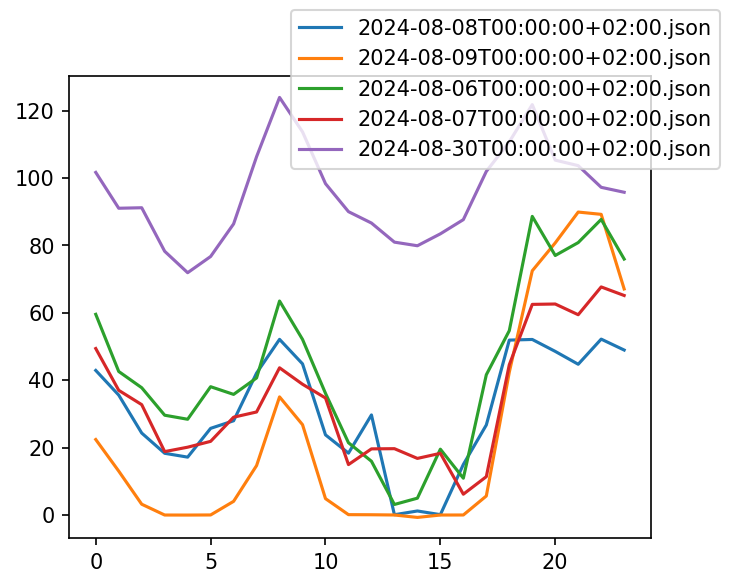

In [81]:
from os import listdir
from os.path import isfile, join
import json 

mypath = '/Users/adrienguenard/Desktop/EF/1.WIP/V2Gopt/EVagr/EVagreg/Price_data/RTE_API'

onlyfiles = [f for f in listdir(mypath) if isfile(join(mypath, f))]

print(len(onlyfiles))

price_matrix = np.zeros((24, len(onlyfiles)))

print(np.shape(price_matrix))
label = []
for j, files in enumerate(onlyfiles): 
    # Read the JSOn files and store them as df
    # Opening JSON file
    f = open(f'{mypath}/{files}')

    # returns JSON object as 
    # a dictionary
    wholesale_data_json = json.load(f)
    

    #Store it also as a df
    for i, value in enumerate(wholesale_data_json['france_power_exchanges'][0]['values']):
        if i == 0:
            df = pd.DataFrame(value, index=[0])
        else:
            df_row = pd.DataFrame(value, index=[0])
            df = pd.concat([df, df_row], axis=0)
    # Reset the index
    df = df.reset_index()
    #Store it in the class
    wholesale_data_df = df

    price_matrix[:,j] = wholesale_data_df['price'].values
    label.append(files)
    
print(price_matrix)

fig, axs = plt.subplots(figsize = (5,4), dpi = 150)

for k in range(np.shape(price_matrix)[1]):
    axs.plot(price_matrix[:,k], label = label[k])

fig.legend()

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


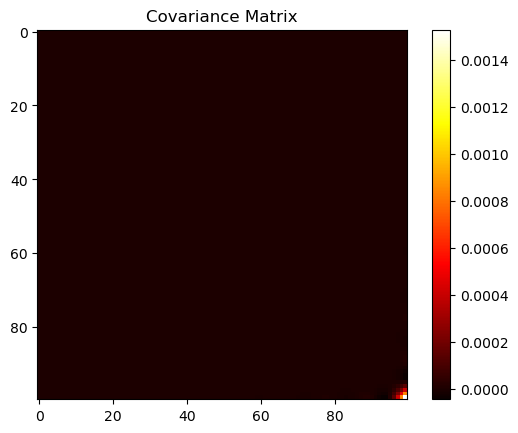

In [89]:
# Assuming data_x is the array of input points and data_y is a (n_samples, n_realizations) matrix of outputs.
data_x = [i for i in range(24)]
print(data_x)

# Estimate mean function (mean of realizations)
mean_y = np.mean(price_matrix, axis=1)
# Initialize the GPR model
gpr_reg = GPR(data_x = data_x, 
          data_y=mean_y,
          covariance_function= SquaredExponentialKernel(sigma_f= 10, length= 3))

# Predict at the original input points
data_to_predict = np.linspace(0,24, 100)
predicted_mean = gpr_reg.predict(data_to_predict)

# Retrieve the covariance matrix from the GPR model
cov_matrix_out = gpr_reg._memory['covariance_matrix']

# Display covariance matrix
plt.imshow(cov_matrix_out, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title("Covariance Matrix")
plt.show()

[0.00077459 0.00132278 0.00137806 0.0010511  0.00078459 0.0007556
 0.00081564 0.00082182 0.0007657  0.00073429 0.00071793 0.00074927
 0.00074213 0.00072939 0.00071414 0.000721   0.00072731 0.00073713
 0.00071051 0.00070735 0.00073149 0.00072361 0.00074567 0.00072897
 0.00071836 0.00073003 0.00072099 0.00072294 0.00071639 0.00070578
 0.00072454 0.00070901 0.00072098 0.0006845  0.00072362 0.00068635
 0.00070606 0.00067687 0.00070204 0.00069985 0.00066732 0.00065051
 0.00069323 0.00068856 0.00069841 0.00068416 0.00069481 0.00070081
 0.00072231 0.00071195 0.00071221 0.00069989 0.00072556 0.00071619
 0.0007144  0.0007298  0.00073719 0.00073241 0.0007233  0.00072547
 0.00070403 0.0007333  0.00072398 0.00075044 0.00070434 0.00072509
 0.00072767 0.00072137 0.00070315 0.00072174 0.000714   0.00071837
 0.00072588 0.00070739 0.0007128  0.00071672 0.00071328 0.00071627
 0.00072137 0.00073173 0.00071122 0.00072157 0.00074025 0.00075142
 0.00074595 0.00073161 0.00074699 0.00079385 0.00082951 0.00081

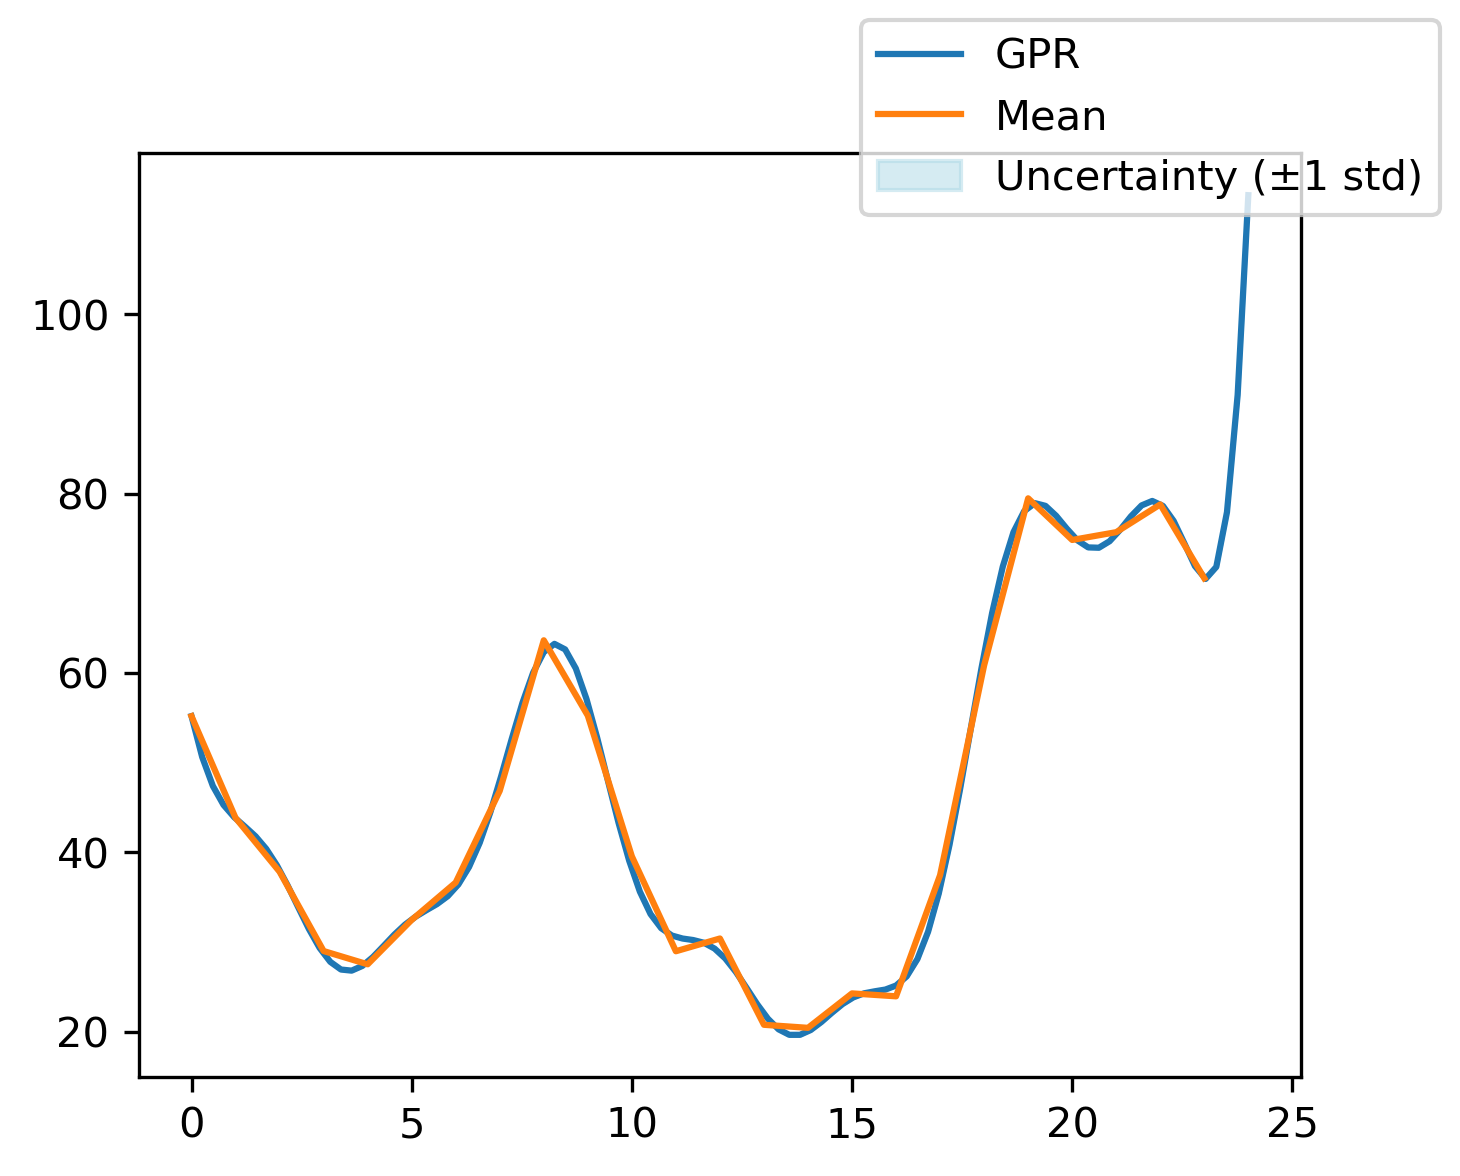

In [91]:
fig, ax = plt.subplots(figsize = (5,4), dpi = 300)
ax.plot(data_to_predict, predicted_mean, label = 'GPR')

# Calculate the standard deviation (square root of variance)
predicted_variance = gpr_reg._memory['variance']
predicted_std = np.sqrt(predicted_variance) 
print(predicted_std)

ax.plot(data_x, mean_y, label = 'Mean')

for k in range(np.shape(price_matrix)[1]):
    #ax.plot(price_matrix[:,k], label = label[k])
    pass


plt.fill_between(data_to_predict, predicted_mean - predicted_std, predicted_mean + predicted_std, color='lightblue', alpha=0.5, label='Uncertainty (±1 std)')
fig.legend()

In [84]:
print(np.shape(price_matrix))
print(np.shape(range(24)))

(24, 5)
(24,)
